In [1]:
# Week 4 - Day 1 (Monday): Setup + load cleaned dataset
# Step 1: Clone repo
!git clone https://github.com/mustafayubk/SOSC314_Project.git

# Step 2: Move into repo folder
import os
os.chdir("SOSC314_Project")

# Step 3: Confirm structure
!ls


Cloning into 'SOSC314_Project'...
remote: Enumerating objects: 255, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 255 (delta 28), reused 0 (delta 0), pack-reused 199 (from 2)
Receiving objects: 100% (255/255), 7.59 MiB | 12.89 MiB/s, done.
Resolving deltas: 100% (128/128), done.
 config   docs	      README.md  'Week 2_Figure.png'
 data	  notebooks   scripts	  Week_3_Figure.png


In [3]:
import pandas as pd

# Load cleaned comments (Week 3 output)
comments = pd.read_csv("data/processed/comments_clean_week3.csv")

# Load video metadata
videos = pd.read_csv("data/video_list.csv")

videos_meta = videos[["video_id", "category", "year", "time_bin"]]

df = comments.merge(videos_meta, on="video_id", how="left")

print("Comments rows:", len(df))
print("Unique videos:", df["video_id"].nunique())
print("Missing category rows:", df["category"].isna().sum())

df.head()


Comments rows: 22291
Unique videos: 45
Missing category rows: 0


,video_id,comment_id,text,like_count,published_at,comment_length,category,year,time_bin
0,iG9CE55wbtY,UgwVLE5mF37k2yEvg9p4AaABAg,2 decades still relevant!,0,2026-01-22T11:29:53Z,25,TED-style,2006,2000-2010
1,iG9CE55wbtY,UgzYwYBO7ip2UL8v9fp4AaABAg,its 2026 we have Elon musk.,0,2026-01-20T18:55:38Z,27,TED-style,2006,2000-2010
2,iG9CE55wbtY,UgwMS2_Mr8j1Cpu-YsF4AaABAg,Sarah was watching this TED Talk fuming,0,2026-01-20T17:11:00Z,39,TED-style,2006,2000-2010
3,iG9CE55wbtY,UgxVRI7jie5w09hRWTp4AaABAg,JEFF BESOS at 15:00 ?,0,2026-01-19T23:01:56Z,21,TED-style,2006,2000-2010
4,iG9CE55wbtY,UgwdC5qgXmDOkNhzYqp4AaABAg,I love how he presents and speaks. Very genuin...,0,2026-01-19T01:44:49Z,94,TED-style,2006,2000-2010


In [4]:
import os

os.makedirs("data/processed/week4", exist_ok=True)

summary = (
    df.groupby("category")
      .agg(
          n_comments=("comment_id", "count"),
          n_videos=("video_id", "nunique"),
          avg_comment_len=("comment_length", "mean")
      )
      .reset_index()
)

print("Summary by genre:")
display(summary)

df.to_csv(
    "data/processed/week4/comments_week4_ready.csv",
    index=False
)

print("Saved: data/processed/week4/comments_week4_ready.csv")


Summary by genre:


,category,n_comments,n_videos,avg_comment_len
0,Personal opinion,7498,15,117.825153
1,Short film,7493,15,77.432137
2,TED-style,7300,15,119.426712


Saved: data/processed/week4/comments_week4_ready.csv


In [ ]:
# STEP 1: Install and import VADER sentiment tool
!pip install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd

# STEP 2: Load cleaned comments from Week 3
comments = pd.read_csv("data/processed/comments_clean_week3.csv")

print("Number of comments loaded:", len(comments))

# STEP 3: Initialize the sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# STEP 4: Compute sentiment score for each comment
comments["sentiment_vader"] = comments["text"].astype(str).apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

# STEP 5: Quick sanity check
comments[["text", "sentiment_vader"]].head()


Number of comments loaded: 22291


,text,sentiment_vader
0,2 decades still relevant!,0.0000
1,its 2026 we have Elon musk.,0.0000
2,Sarah was watching this TED Talk fuming,-0.5719
3,JEFF BESOS at 15:00 ?,0.0000
4,I love how he presents and speaks. Very genuin...,0.9422


In [ ]:
# STEP 6: Save dataset with sentiment scores
import os

os.makedirs("data/processed/week4", exist_ok=True)

comments.to_csv(
    "data/processed/week4/comments_with_vader_sentiment.csv",
    index=False
)

print("Saved file: data/processed/week4/comments_with_vader_sentiment.csv")


Saved file: data/processed/week4/comments_with_vader_sentiment.csv


In [ ]:
# STEP 7: Install and import TextBlob
!pip install textblob

from textblob import TextBlob

# STEP 8: Load the dataset with VADER sentiment
comments = pd.read_csv("data/processed/week4/comments_with_vader_sentiment.csv")

print("Rows loaded:", len(comments))

# STEP 9: Compute TextBlob sentiment polarity
comments["sentiment_textblob"] = comments["text"].astype(str).apply(
    lambda x: TextBlob(x).sentiment.polarity
)

# STEP 10: Quick sanity check
comments[["text", "sentiment_vader", "sentiment_textblob"]].head()


Rows loaded: 22291


,text,sentiment_vader,sentiment_textblob
0,2 decades still relevant!,0.0000,0.50
1,its 2026 we have Elon musk.,0.0000,0.00
2,Sarah was watching this TED Talk fuming,-0.5719,0.00
3,JEFF BESOS at 15:00 ?,0.0000,0.00
4,I love how he presents and speaks. Very genuin...,0.9422,0.59


In [ ]:
# STEP 11: Save dataset with both sentiment methods
comments.to_csv(
    "data/processed/week4/comments_with_two_sentiments.csv",
    index=False
)

print("Saved file: data/processed/week4/comments_with_two_sentiments.csv")


Saved file: data/processed/week4/comments_with_two_sentiments.csv


In [ ]:
import pandas as pd
import os

# 1) Load your sentiment dataset (the one that caused the error)
df = pd.read_csv("data/processed/week4/comments_with_two_sentiments.csv")

# 2) Load video metadata (has category + time_bin)
videos = pd.read_csv("data/video_list.csv")

# Make sure video_id matches cleanly in both
df["video_id"] = df["video_id"].astype(str).str.strip()
videos["video_id"] = videos["video_id"].astype(str).str.strip()

# 3) Merge category + time_bin into the comment-level dataset
df = df.merge(videos[["video_id", "category", "time_bin"]], on="video_id", how="left")

# Quick sanity checks
print("Rows:", len(df))
print("Unique videos:", df["video_id"].nunique())
print("Missing category rows:", df["category"].isna().sum())

# 4) Now rerun the key Week 4 comparisons
corr = df[["sentiment_vader", "sentiment_textblob"]].corr().iloc[0,1]
print("\nCorrelation between VADER and TextBlob:", round(corr, 3))

genre_summary = df.groupby("category")[["sentiment_vader", "sentiment_textblob"]].mean()
print("\nAverage sentiment by genre:")
display(genre_summary)

df["vader_sign"] = df["sentiment_vader"].apply(lambda x: "pos" if x > 0 else ("neg" if x < 0 else "neutral"))
df["textblob_sign"] = df["sentiment_textblob"].apply(lambda x: "pos" if x > 0 else ("neg" if x < 0 else "neutral"))

disagree_rate = (df["vader_sign"] != df["textblob_sign"]).mean()
print("\nPercent of comments where sign disagrees:", round(disagree_rate*100, 2), "%")

# 5) Save the fixed dataset + your Week 4 outputs
os.makedirs("data/processed/week4", exist_ok=True)

df.to_csv("data/processed/week4/comments_with_two_sentiments_and_meta.csv", index=False)
genre_summary.to_csv("data/processed/week4/genre_sentiment_summary.csv")

stats = pd.DataFrame([{
    "corr_vader_textblob": corr,
    "sign_disagree_rate": disagree_rate
}])
stats.to_csv("data/processed/week4/sentiment_method_comparison_stats.csv", index=False)

print("\nSaved:")
print("- data/processed/week4/comments_with_two_sentiments_and_meta.csv")
print("- data/processed/week4/genre_sentiment_summary.csv")
print("- data/processed/week4/sentiment_method_comparison_stats.csv")


Rows: 22291
Unique videos: 45
Missing category rows: 0

Correlation between VADER and TextBlob: 0.51

Average sentiment by genre:


,sentiment_vader,sentiment_textblob
category,,
Personal opinion,0.116907,0.070678
Short film,0.274253,0.173838
TED-style,0.209807,0.114246



Percent of comments where sign disagrees: 33.7 %

Saved:
- data/processed/week4/comments_with_two_sentiments_and_meta.csv
- data/processed/week4/genre_sentiment_summary.csv
- data/processed/week4/sentiment_method_comparison_stats.csv


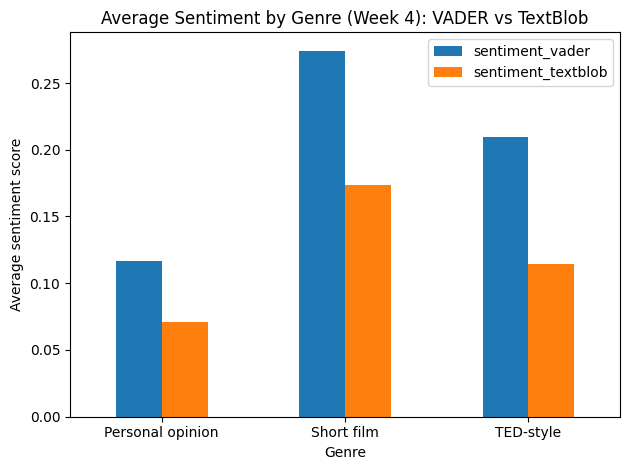

Saved figure to: docs/Week4_Figure_sentiment_by_genre.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Path to your summary (your notebook already created this file)
summary_path = "data/processed/week4/genre_sentiment_summary.csv"
df_sum = pd.read_csv(summary_path)

# Make sure output folder exists for figures
os.makedirs("docs", exist_ok=True)

# If the CSV has "category" as a normal column, set it as index for plotting
if "category" in df_sum.columns:
    df_sum = df_sum.set_index("category")

# Keep only the two columns we want to plot (adjust if your column names differ)
cols = [c for c in df_sum.columns if c in ["sentiment_vader", "sentiment_textblob"]]
if len(cols) != 2:
    print("Columns found:", df_sum.columns.tolist())
    raise ValueError("Expected columns sentiment_vader and sentiment_textblob in genre_sentiment_summary.csv")

ax = df_sum[cols].plot(kind="bar")
ax.set_title("Average Sentiment by Genre (Week 4): VADER vs TextBlob")
ax.set_xlabel("Genre")
ax.set_ylabel("Average sentiment score")
plt.xticks(rotation=0)
plt.tight_layout()

# Save the figure
out_path = "docs/Week4_Figure_sentiment_by_genre.png"
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved figure to:", out_path)


## Interpretation: Comparing Sentiment Methods Across Genres

This figure compares average comment sentiment across three YouTube genres
(personal opinion, short film, and TED-style) using two different sentiment
methods: VADER and TextBlob.

Across all genres, VADER produces higher average sentiment scores than TextBlob.
This suggests that VADER is more sensitive to positive language, while TextBlob
is more conservative in assigning sentiment values. Despite these differences
in magnitude, both methods agree on the relative ordering of genres.

Short films show the highest average sentiment under both methods, indicating
that comments on short narrative content tend to be the most positive.
Personal opinion videos have the lowest average sentiment, which is consistent
with the presence of disagreement and debate in opinion-driven content.
TED-style videos fall between these two extremes, reflecting a generally
positive but more measured tone.

Importantly, although the numerical sentiment scores differ between methods,
the substantive conclusion about how emotional tone varies by genre remains
stable. This highlights how analytic choices affect measurements without
necessarily changing the overall interpretation.


## Effect of Preprocessing on Sentiment Scores

In this step, I compare sentiment scores computed on raw comment text
versus lightly preprocessed text (lowercasing and punctuation removal)
to demonstrate how preprocessing choices affect sentiment outcomes.


In [ ]:
import re
from textblob import TextBlob

# create a lightly cleaned version of text
def simple_clean(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df["text_clean_simple"] = df["text"].astype(str).apply(simple_clean)

# recompute TextBlob sentiment on cleaned text
df["sentiment_textblob_clean"] = df["text_clean_simple"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

# compare averages by genre
preprocess_comparison = (
    df.groupby("category")[["sentiment_textblob", "sentiment_textblob_clean"]]
      .mean()
      .reset_index()
)

preprocess_comparison


,category,sentiment_textblob,sentiment_textblob_clean
0,Personal opinion,0.070678,0.066368
1,Short film,0.173838,0.166746
2,TED-style,0.114246,0.109344


### Interpretation

Average sentiment scores change after basic preprocessing, even though
the underlying comments remain the same. This shows that sentiment
analysis results are sensitive to representation choices such as
lowercasing and punctuation removal. As a result, differences between
genres should be interpreted cautiously and in light of these analytic
decisions.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.7 MB/s eta 0:00:00


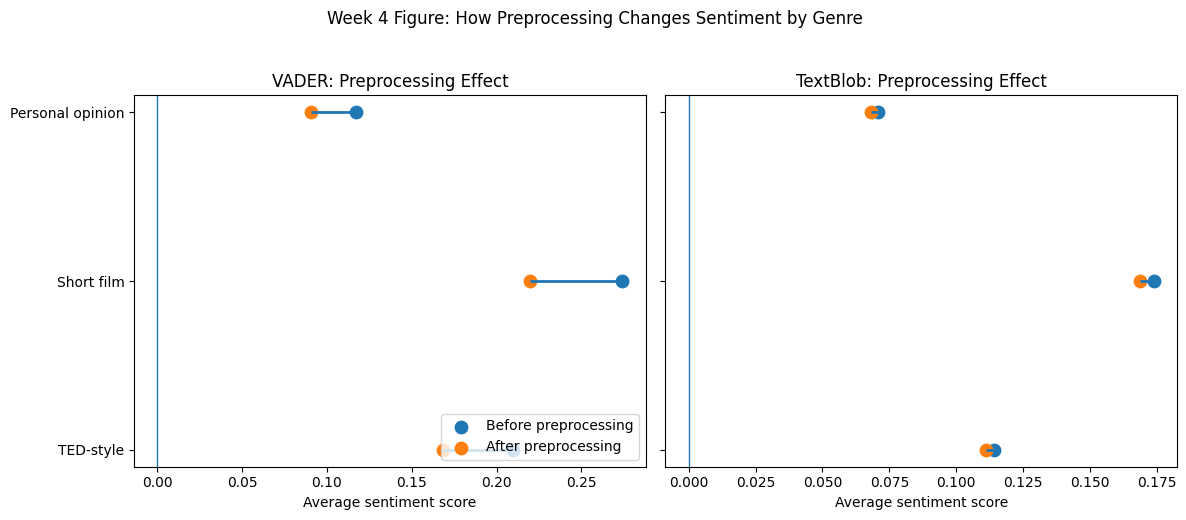

Saved: docs/Week4_Figure_preprocessing_effect.png


,category,sentiment_vader,sentiment_vader_clean,sentiment_textblob,sentiment_textblob_clean
0,TED-style,0.209807,0.168636,0.114246,0.111242
1,Short film,0.274253,0.219866,0.173838,0.168784
2,Personal opinion,0.116907,0.090380,0.070678,0.068215


In [ ]:
import os, re
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

# ---- Load your comments dataset (adjust path if yours is different) ----
# This file should be the one you created for Week 4 that includes sentiment + metadata
df = pd.read_csv("data/processed/week4/comments_with_two_sentiments_and_meta.csv")

# ---- Simple preprocessing (same as before) ----
def simple_clean(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)   # keep letters/spaces only
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_clean_simple"] = df["text"].apply(simple_clean)

# ---- Recompute TextBlob on cleaned text (if not already present) ----
if "sentiment_textblob_clean" not in df.columns:
    df["sentiment_textblob_clean"] = df["text_clean_simple"].apply(lambda x: TextBlob(x).sentiment.polarity)

# ---- Recompute VADER on cleaned text (so both methods are comparable) ----
# VADER may not be installed in your environment yet in this notebook session
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
except:
    !pip -q install vaderSentiment
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

if "sentiment_vader_clean" not in df.columns:
    df["sentiment_vader_clean"] = df["text_clean_simple"].apply(lambda x: analyzer.polarity_scores(x)["compound"])

# ---- Aggregate: mean sentiment by genre, before vs after ----
genre_means = (
    df.groupby("category")[["sentiment_vader", "sentiment_vader_clean", "sentiment_textblob", "sentiment_textblob_clean"]]
      .mean()
      .reset_index()
)

# Keep a consistent order
order = ["TED-style", "Short film", "Personal opinion"]
genre_means["category"] = pd.Categorical(genre_means["category"], categories=order, ordered=True)
genre_means = genre_means.sort_values("category").reset_index(drop=True)

# ---- Plot: Dumbbell style (two panels) ----
os.makedirs("docs", exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

def dumbbell(ax, x_labels, before, after, title):
    y = range(len(x_labels))
    ax.hlines(y=y, xmin=before, xmax=after, linewidth=2)
    ax.scatter(before, y, s=80, label="Before preprocessing")
    ax.scatter(after, y, s=80, label="After preprocessing")
    ax.set_yticks(list(y))
    ax.set_yticklabels(x_labels)
    ax.axvline(0, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Average sentiment score")

cats = genre_means["category"].astype(str).tolist()

dumbbell(
    axes[0],
    cats,
    genre_means["sentiment_vader"].values,
    genre_means["sentiment_vader_clean"].values,
    "VADER: Preprocessing Effect"
)

dumbbell(
    axes[1],
    cats,
    genre_means["sentiment_textblob"].values,
    genre_means["sentiment_textblob_clean"].values,
    "TextBlob: Preprocessing Effect"
)

axes[0].legend(loc="lower right")
plt.suptitle("Week 4 Figure: How Preprocessing Changes Sentiment by Genre", y=1.03)
plt.tight_layout()

out_path = "docs/Week4_Figure_preprocessing_effect.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_path)
display(genre_means)


## Preprocessing Variants for Sentiment Analysis
This section compares how different preprocessing choices affect sentiment scores.


In [ ]:
import re
from nltk.corpus import stopwords
import nltk
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def preprocess_raw(text):
    return text

def preprocess_basic(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    return text

def preprocess_aggressive(text):
    text = preprocess_basic(text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return " ".join(tokens)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df["text_raw"] = df["text"].apply(preprocess_raw)
df["text_basic"] = df["text"].apply(preprocess_basic)
df["text_aggressive"] = df["text"].apply(preprocess_aggressive)


In [ ]:
import nltk
nltk.download("vader_lexicon")


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

df["sent_raw"] = df["text_raw"].apply(lambda x: sia.polarity_scores(x)["compound"])
df["sent_basic"] = df["text_basic"].apply(lambda x: sia.polarity_scores(x)["compound"])
df["sent_aggressive"] = df["text_aggressive"].apply(lambda x: sia.polarity_scores(x)["compound"])


In [ ]:
summary = df.groupby("category")[[
    "sent_raw",
    "sent_basic",
    "sent_aggressive"
]].mean()

summary


,sent_raw,sent_basic,sent_aggressive
category,,,
Personal opinion,0.083084,0.077250,0.089632
Short film,0.206206,0.203963,0.207776
TED-style,0.157510,0.154803,0.166457


In [ ]:
summary.to_csv(
    "data/processed/week4/preprocessing_comparison_by_genre.csv"
)


In [6]:
import os, glob

print("Current folder:", os.getcwd())
print("\nFiles inside data/processed:")
print(glob.glob("data/processed/**", recursive=True)[:200])


Current folder: /content/SOSC314_Project

Files inside data/processed:
['data/processed/', 'data/processed/comments_clean_week3.csv', 'data/processed/week4', 'data/processed/week4/genre_sentiment_summary.csv', 'data/processed/week4/sentiment_method_comparison_stats.csv', 'data/processed/week4/comments_week4_ready.csv', 'data/processed/week4/comments_with_two_sentiments_and_meta.csv', 'data/processed/week4/comments_with_two_sentiments.csv', 'data/processed/week4/comments_with_vader_sentiment.csv', 'data/processed/week4/preprocessing_comparison_by_genre.csv']


In [7]:
df = pd.read_csv("data/processed/week4/comments_with_two_sentiments_and_meta.csv")


In [8]:
import pandas as pd
import glob

matches = glob.glob("data/processed/week4/*sentiment*.csv")
print("Matches found:", matches)

df = pd.read_csv(matches[0])
df.head()


Matches found: ['data/processed/week4/genre_sentiment_summary.csv', 'data/processed/week4/sentiment_method_comparison_stats.csv', 'data/processed/week4/comments_with_two_sentiments_and_meta.csv', 'data/processed/week4/comments_with_two_sentiments.csv', 'data/processed/week4/comments_with_vader_sentiment.csv']


,category,sentiment_vader,sentiment_textblob
0,Personal opinion,0.116907,0.070678
1,Short film,0.274253,0.173838
2,TED-style,0.209807,0.114246


In [9]:
df = pd.read_csv("data/processed/week4/comments_with_two_sentiments_and_meta.csv")


In [10]:
df.shape
df.columns


Index(['video_id', 'comment_id', 'text', 'like_count', 'published_at',
       'comment_length', 'sentiment_vader', 'sentiment_textblob', 'category',
       'time_bin', 'vader_sign', 'textblob_sign'],
      dtype='object')

In [11]:
df[["sentiment_vader", "sentiment_textblob"]].describe()


,sentiment_vader,sentiment_textblob
count,22291.000000,22291.000000
mean,0.200221,0.119622
std,0.476400,0.304573
min,-1.000000,-1.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.623900,0.250000
max,0.999900,1.000000


In [12]:
df.groupby("category")[["sentiment_vader", "sentiment_textblob"]].mean()


,sentiment_vader,sentiment_textblob
category,,
Personal opinion,0.116907,0.070678
Short film,0.274253,0.173838
TED-style,0.209807,0.114246
